DIA_Deep2S_main.py
------------------
Differential Injection Attack (DIA) on the Deep2S learned reconstruction model
for 3D near-field MIMO imaging.

Pipeline:
    1) Load physics-based observation operator A and pretrained Deep2S model.
    
    2) Load clean experimental measurements y_clean and attack dictionary D_flat.
    
    3) Define the Deep2S forward operator (A^H y + 3D UNet denoiser).
    
    4) Construct a "blank" target volume (camouflage objective).
    
    5) Optimize complex per-aperture gains A_p under |A_p| <= Amax using a
       reparameterization A = Amax/sqrt(2) * tanh(Z).
       
    6) Reconstruct and visualize clean vs. attacked Deep2S images.
    
    7) Report quantitative MIP-level attack metrics (MSE, NCC, SSIM, PSNR).

This file is intended as the main reproducible implementation of the DIA
on Deep2S for the paper.

In [20]:
# ============================================================
# 0. Imports & basic configuration
# ============================================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

from src import src, misc   # Deep2S codebase: UNet3D + helper utilities

pltr = misc.Plotter()       # not strictly required, but available if needed

# Reproducibility
np.random.seed(0)
tf.random.set_seed(0)

In [21]:
# ============================================================
# 1. Load observation model A, Deep2S model, and measurements
# ============================================================

# --- 1.1 Load physics-based observation model A ---
# A: (K, T, R, X, Y, Z)
#   K: #frequency steps
#   T: #TX antennas
#   R: #RX antennas
#   X,Y,Z: voxel grid dimensions
A_path = "models/experimental/A15_exp.npy"
A = np.load(A_path)  # complex-valued array
print("A.shape =", A.shape)
K, T, R, X, Y, Z = A.shape

# --- 1.2 Load clean experimental measurements y_clean ---
# y_clean: (1, K, T, R)   (leading 1 is batch dimension)
y_clean_path = "data/y_exp_test_4.npy"
y_exp = np.load(y_clean_path)                     # (K, T, R)
y_clean = y_exp[None, ...].astype(np.complex64)   # (1, K, T, R)
print("y_clean.shape =", y_clean.shape)

# --- 1.3 Load pretrained Deep2S UNet3D model ---
# DNN input:  (X, Y, Z, 1)
# DNN output: (X, Y, Z, 1)
DNN = src.get_UNet3D(input_shape=(X, Y, Z, 1))
DNN.load_weights("models/experimental/Deep2S/model_Nf15_SNR30_exp.h5")
print("Loaded Deep2S UNet3D weights.")

A.shape = (15, 16, 9, 25, 25, 49)
y_clean.shape = (1, 15, 16, 9)
Loaded Deep2S UNet3D weights.


In [22]:
# ============================================================
# 2. Flatten measurements and load attack dictionary D_flat
# ============================================================

# X_v_flat: victim measurements flattened over aperture positions
# shape: (K, Np) where Np = T * R
_, Kb, Tb, Rb = y_clean.shape
assert (Kb, Tb, Rb) == (K, T, R)
Np = T * R

X_v_flat = y_clean[0].reshape(K, Np)  # (K, Np)
print("Flattened victim measurements X_v_flat shape:", X_v_flat.shape)

# D_flat: attack dictionary, precomputed from real attack waveforms (X_aa)
# shape: (K, Np), complex64, RMS-normalized per column in MATLAB.
D_flat_path = "data/D_flat.npy"
D_flat_np = np.load(D_flat_path)      # (K, Np), complex
assert D_flat_np.shape == X_v_flat.shape
print("Loaded D_flat from:", D_flat_path, "with shape", D_flat_np.shape)

# Cast to TF for gradient-based optimization
D_flat       = tf.constant(D_flat_np.astype(np.complex64))          # (K, Np)
X_v_flat_tf  = tf.constant(X_v_flat.astype(np.complex64))           # (K, Np)

Flattened victim measurements X_v_flat shape: (15, 144)
Loaded D_flat from: data/D_flat.npy with shape (15, 144)


In [23]:
# ============================================================
# 3. TF constants for A and A^H
# ============================================================

A_tf      = tf.constant(A.astype(np.complex64))    # (K,T,R,X,Y,Z)
A_conj_tf = tf.math.conj(A_tf)

In [24]:
# ============================================================
# 4. Deep2S forward operator (A^H y + UNet3D)
# ============================================================

def deep2s_forward_tf(y_batch):
    """
    Deep2S forward mapping implemented in TensorFlow.

    Args
    ----
    y_batch : tf.Tensor, shape (N, K, T, R), complex64
        Batch of measurement vectors.

    Returns
    -------
    x_hat_mag : tf.Tensor, shape (N, X, Y, Z), float32
        RMS-normalized reconstructed magnitude volumes.
    """
    # 1) Adjoint physics: A^H y  (N,K,T,R) -> (N,X,Y,Z)
    AHy = tf.einsum('ktrxyz,Nktr->Nxyz', A_conj_tf, y_batch)  # complex

    # 2) Magnitude + per-batch max normalization
    mag     = tf.abs(AHy)                                      # (N,X,Y,Z)
    max_mag = tf.reduce_max(mag, axis=(1, 2, 3), keepdims=True)
    mag_norm = mag / (max_mag + 1e-12)

    # 3) Pass through UNet3D denoiser prior
    x_hat = DNN(mag_norm[..., None], training=False)           # (N,X,Y,Z,1) or (N,X,Y,Z)

    if tf.is_tensor(x_hat) and x_hat.dtype.is_complex:
        x_hat = tf.abs(x_hat)

    if len(x_hat.shape) == 5:
        x_hat = x_hat[..., 0]                                  # (N,X,Y,Z)

    # 4) RMS normalization (to match MATLAB trueImage_abs / rms)
    rms = tf.sqrt(tf.reduce_mean(x_hat**2, axis=(1, 2, 3), keepdims=True) + 1e-12)
    x_hat = x_hat / rms

    return x_hat  # (N,X,Y,Z)

# Clean Deep2S reconstruction (for reference and plotting)
x_clean_mag = deep2s_forward_tf(tf.constant(y_clean)).numpy()[0]  # (X,Y,Z)

In [25]:
# ============================================================
# 5. Construct "blank" camouflage target volume
# ============================================================

# 2D MIP of the clean reconstruction (for choosing a background level)
clean_mip   = x_clean_mag.max(axis=2)             # (X,Y)
bg_val      = float(clean_mip[0, 0])              # dark corner pixel
drange      = float(clean_mip.max() - clean_mip.min())

# Base constant background
base = np.full((X, Y, Z), bg_val, dtype=np.float32)

# Small random perturbation around bg_val (5% of dynamic range)
np.random.seed(1234)
noise_std = 0.05 * drange
noise     = noise_std * np.random.randn(X, Y, Z).astype(np.float32)

x_target = base + noise
x_target = np.clip(x_target, 0.0, None)

# Optional RMS normalization of the target
rms_tgt   = np.sqrt(np.mean(x_target**2) + 1e-12)
x_target  = x_target / rms_tgt

x_target_tf = tf.constant(x_target[None, ...])   # (1,X,Y,Z)
x_target_mip = x_target.max(axis=2)

In [26]:
# ============================================================
# 6. Attack loss: optimize complex gains A via reparameterization
# ============================================================

def attack_loss(A_re, A_im, lambda_L2=0.0):
    """
    Attack objective:
        1) Build attacked measurements Y = X_v_flat + D_flat * A^T.
        2) Run Deep2S forward to get x_att.
        3) Minimize image-domain MSE to x_target + L2 regularization on A.

    Args
    ----
    A_re, A_im : tf.Tensor, shape (Np,), float32
        Real and imaginary parts of the complex gains A_p.
    lambda_L2  : float
        Weight for L2 penalty on |A|^2.

    Returns
    -------
    loss_total : scalar Tensor
        Total loss = image MSE + lambda_L2 * L2(A).
    loss_im    : scalar Tensor
        Image-domain MSE term only.
    reg        : scalar Tensor
        L2 regularization term.
    x_hat_mag  : tf.Tensor, shape (1, X, Y, Z)
        Current attacked reconstruction.
    """
    # Complex gains A: (Np,)
    A_complex = tf.complex(A_re, A_im)
    A_col     = tf.reshape(A_complex, (1, Np))        # (1,Np)

    # Attacked flattened measurements: (K,Np)
    Y_flat = X_v_flat_tf + D_flat * A_col

    # Reshape back to (1,K,T,R)
    Y_batch = tf.reshape(Y_flat, (1, K, T, R))

    # Deep2S reconstruction
    x_hat_mag = deep2s_forward_tf(Y_batch)            # (1,X,Y,Z)

    # Image-domain MSE to target
    loss_im = tf.reduce_mean((x_hat_mag - x_target_tf)**2)

    # L2 regularization on A
    reg = lambda_L2 * tf.reduce_mean(tf.abs(A_complex)**2)

    return loss_im + reg, loss_im, reg, x_hat_mag

In [27]:
# ============================================================
# 7. DIA loop
# ============================================================
# ---  Reparameterize A and set up Adam optimizer ---

Amax      = 2.0        # physical amplitude bound on |A_p|
lambda_L2 = 1e-5       # L2 weight (can tune 1e-4–1e-2)
max_iter  = 300        # number of attack iterations

# Latent variables Z; A will be obtained via a tanh mapping
Z_re = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))
Z_im = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))

def get_A_from_Z(Z_re, Z_im, Amax=2.0):
    """
    Smooth parameterization:

        A_re = (Amax / sqrt(2)) * tanh(Z_re)
        A_im = (Amax / sqrt(2)) * tanh(Z_im)

    so that each component lies in [-Amax/sqrt(2), Amax/sqrt(2)],
    which guarantees |A_p| <= Amax without hard projection.
    """
    scale = Amax / np.sqrt(2.0)
    A_re = scale * tf.tanh(Z_re)
    A_im = scale * tf.tanh(Z_im)
    return A_re, A_im

# Adam with simple 2-stage learning-rate schedule
optimizer      = tf.keras.optimizers.Adam(learning_rate=1e-1)
lr_switch_iter = 100
low_lr         = 1e-2

loss_hist  = []
meanA_hist = []
maxA_hist  = []

print("\nStarting attack optimization on Deep2S (Np = {})...".format(Np))

for it in range(1, max_iter + 1):

    # Learning-rate schedule: high LR, then lower after lr_switch_iter
    if it == lr_switch_iter + 1:
        optimizer.learning_rate.assign(low_lr)
        print(f"\n[LR SCHEDULE] Switched Adam LR to {low_lr}\n")

    with tf.GradientTape() as tape:
        A_re_cur, A_im_cur = get_A_from_Z(Z_re, Z_im, Amax=Amax)
        loss_total, loss_im, reg, x_hat_mag = attack_loss(
            A_re_cur, A_im_cur, lambda_L2=lambda_L2
        )

    grads = tape.gradient(loss_total, [Z_re, Z_im])
    optimizer.apply_gradients(zip(grads, [Z_re, Z_im]))

    # Logging statistics
    A_re_val, A_im_val = get_A_from_Z(Z_re, Z_im, Amax=Amax)
    A_complex = tf.complex(A_re_val, A_im_val)
    A_now = A_complex.numpy()
    meanA = np.mean(np.abs(A_now))
    maxA  = np.max(np.abs(A_now))

    loss_hist.append(loss_total.numpy().item())
    meanA_hist.append(meanA)
    maxA_hist.append(maxA)

    if (it == 1) or (it % 5 == 0) or (it == max_iter):
        print(
            f"Iter {it:3d}/{max_iter:3d} | "
            f"Loss={loss_total.numpy():.6e} | "
            f"loss_im={loss_im.numpy():.6e} | reg={reg.numpy():.6e} | "
            f"mean|A|={meanA:.3e}, max|A|={maxA:.3e}"
        )

print("Attack optimization finished.")


Starting attack optimization on Deep2S (Np = 144)...
Iter   1/300 | Loss=1.754510e+00 | loss_im=1.754510e+00 | reg=4.336306e-11 | mean|A|=1.972e-01, max|A|=2.020e-01
Iter   5/300 | Loss=1.708733e+00 | loss_im=1.708730e+00 | reg=2.284345e-06 | mean|A|=5.089e-01, max|A|=8.959e-01
Iter  10/300 | Loss=1.676884e+00 | loss_im=1.676878e+00 | reg=6.116143e-06 | mean|A|=7.540e-01, max|A|=1.434e+00
Iter  15/300 | Loss=1.658988e+00 | loss_im=1.658979e+00 | reg=9.145829e-06 | mean|A|=8.968e-01, max|A|=1.683e+00
Iter  20/300 | Loss=1.643744e+00 | loss_im=1.643733e+00 | reg=1.136186e-05 | mean|A|=9.913e-01, max|A|=1.788e+00
Iter  25/300 | Loss=1.623446e+00 | loss_im=1.623433e+00 | reg=1.309506e-05 | mean|A|=1.063e+00, max|A|=1.871e+00
Iter  30/300 | Loss=1.582260e+00 | loss_im=1.582245e+00 | reg=1.491245e-05 | mean|A|=1.143e+00, max|A|=1.908e+00
Iter  35/300 | Loss=1.532361e+00 | loss_im=1.532344e+00 | reg=1.678046e-05 | mean|A|=1.228e+00, max|A|=1.935e+00
Iter  40/300 | Loss=1.510097e+00 | loss_im

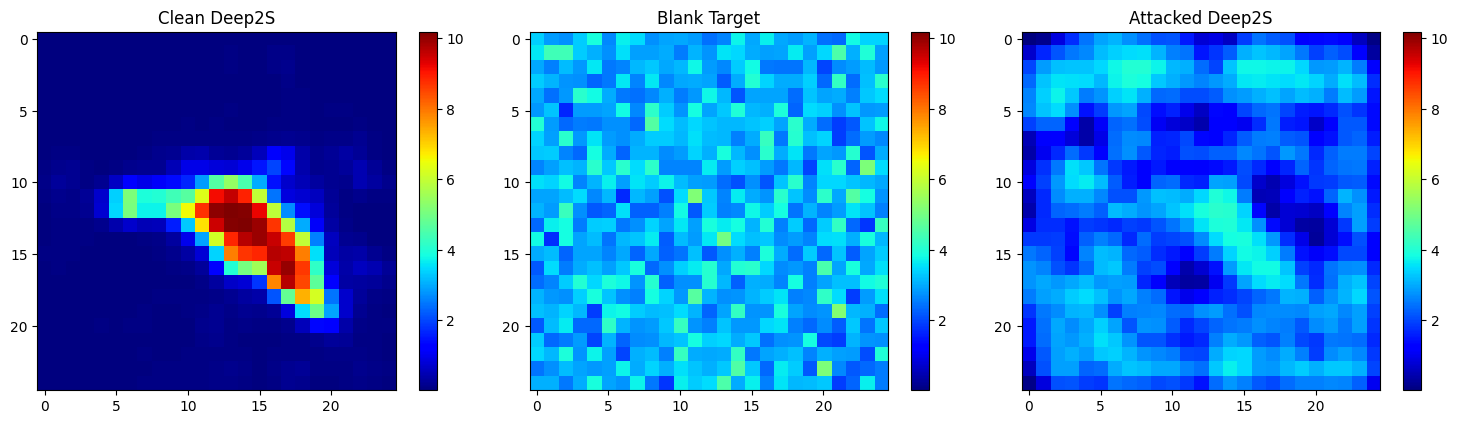

In [17]:
# ============================================================
# 8. Final attacked reconstruction and visualization
# ============================================================

# Compute final optimized A from Z
A_re_opt, A_im_opt = get_A_from_Z(Z_re, Z_im, Amax=Amax)
A_opt_tf  = tf.complex(A_re_opt, A_im_opt)       # (Np,)
A_opt_col = tf.reshape(A_opt_tf, (1, Np))        # (1,Np)

# Build attacked measurements and reconstruct
Y_opt_flat_tf = X_v_flat_tf + D_flat * A_opt_col       # (K,Np)
Y_opt_tf      = tf.reshape(Y_opt_flat_tf, (1, K, T, R))
x_att_mag     = deep2s_forward_tf(Y_opt_tf).numpy()[0]  # (X,Y,Z)

# 2D MIPs over depth
clean_mip     = x_clean_mag.max(axis=2)
att_mip       = x_att_mag.max(axis=2)
x_target_mip  = x_target.max(axis=2)

vmin = clean_mip.min()
vmax = clean_mip.max()

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(clean_mip, origin='upper', cmap='jet', vmin=vmin, vmax=vmax)
plt.title('Clean Deep2S')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(x_target_mip, origin='upper', cmap='jet', vmin=vmin, vmax=vmax)
plt.title('Blank Target (MIP)')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(att_mip, origin='upper', cmap='jet', vmin=vmin, vmax=vmax)
plt.title('Attacked Deep2S')
plt.colorbar()

plt.tight_layout()
plt.show()

========================================================== Attack End

In [18]:
# ============================================================
# 9. Quantitative evaluation
# ============================================================

mse_mip  = np.mean((att_mip - x_target_mip) ** 2)
rmse_mip = np.sqrt(mse_mip)
mae_mip  = np.mean(np.abs(att_mip - x_target_mip))

num = np.sum(att_mip * x_target_mip)
den = np.sqrt(np.sum(att_mip**2) * np.sum(x_target_mip**2)) + 1e-12
ncc_mip = num / den

data_range = float(x_target_mip.max() - x_target_mip.min() + 1e-12)
ssim_mip = ssim(att_mip, x_target_mip, data_range=data_range)
psnr_mip = psnr(x_target_mip, att_mip, data_range=data_range)

print("\n--- MIP-level attack metrics ---")
print(f"MSE   : {mse_mip:.4e}")
print(f"RMSE  : {rmse_mip:.4e}")
print(f"MAE   : {mae_mip:.4e}")
print(f"NCC   : {ncc_mip:.4f}")
print(f"SSIM  : {ssim_mip:.4f}")
print(f"PSNR  : {psnr_mip:.2f} dB")


--- MIP-level attack metrics ---
MSE   : 1.7197e+00
RMSE  : 1.3114e+00
MAE   : 1.0403e+00
NCC   : 0.9195
SSIM  : 0.0119
PSNR  : 8.65 dB
